In [1]:
# Import & Load data (pastikan paket penting terpasang)
import sys, subprocess, importlib
from pathlib import Path
# import nama yg umum dipakai setelah memastikan package terpasang
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Resolve relative data file (cari beberapa lokasi yang mungkin)
data_candidates = [
    Path('data') / 'master' / 'Master Data - fitur & label.xlsx',
    Path('..') / 'data' / 'master' / 'Master Data - fitur & label.xlsx',
    Path.cwd().parent / 'data' / 'master' / 'Master Data - fitur & label.xlsx',
]
tried = [str(p.resolve()) for p in data_candidates]
existing = [p for p in data_candidates if p.exists()]
if existing:
    path = existing[0]
else:
    raise FileNotFoundError(f"Master Data not found. Tried the following locations: {tried}")
print('Using data file:', path.resolve())
df = pd.read_excel(path)

# Setup outputs base & figures/tables dirs (relatif)
out_candidates = [
    Path('outputs'),
    Path('..') / 'outputs',
    Path.cwd().parent / 'outputs',
]
base_out = next((p for p in out_candidates if p.exists()), out_candidates[0])
base_out.mkdir(parents=True, exist_ok=True)
figures_dir = base_out / 'figures'
tables_dir = base_out / 'tables'
figures_dir.mkdir(parents=True, exist_ok=True)
tables_dir.mkdir(parents=True, exist_ok=True)

print(df.shape)
display(df.head())


Using data file: C:\Users\femmy\OneDrive\Documents\6. Semester 6\tugas_akhir_machine_learning-main\data\master\Master Data - fitur & label.xlsx


(27, 19)


,kode_kab_kota,kab_kota,luas_km2,kepadatan_penduduk,apotek,puskesmas_total,klinik,rsu_total,penduduk_2024,rasio_apotek,dens_apotek,rasio_puskesmas_total,dens_puskesmas_total,rasio_klinik,dens_klinik,rasio_rsu_total,dens_rsu_total,skor_layanan,kelas_layanan
0,3201,KABUPATEN BOGOR,2991.78,1899,466,258,45,27,5681390.22,0.820222,0.155760,0.454114,0.086236,0.079206,0.015041,0.047524,0.009025,-0.771693,Rendah
1,3202,KABUPATEN SUKABUMI,4164.15,679,206,282,9,9,2827457.85,0.728570,0.049470,0.997362,0.067721,0.031831,0.002161,0.031831,0.002161,-0.616339,Rendah
2,3203,KABUPATEN CIANJUR,3631.92,712,219,157,10,7,2585927.04,0.846892,0.060299,0.607132,0.043228,0.038671,0.002753,0.027070,0.001927,-0.843022,Rendah
3,3204,KABUPATEN BANDUNG,1740.84,2156,418,100,14,17,3753251.04,1.113701,0.240114,0.266436,0.057444,0.037301,0.008042,0.045294,0.009765,-0.910243,Rendah
4,3205,KABUPATEN GARUT,3101.24,876,325,276,10,9,2716686.24,1.196310,0.104797,1.015944,0.088997,0.036810,0.003225,0.033129,0.002902,-0.413293,Rendah


<Figure size 1000x400 with 0 Axes>

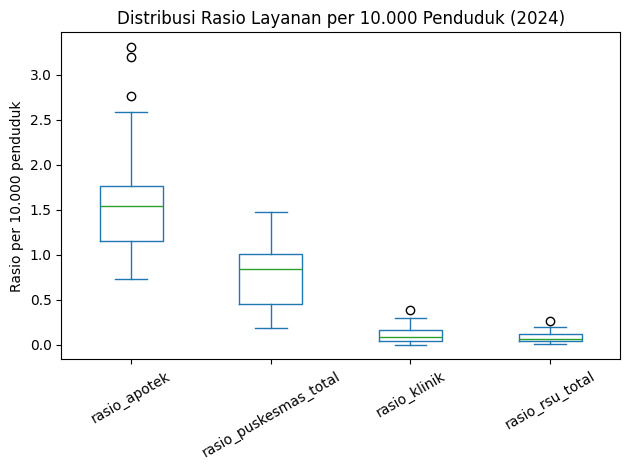

In [2]:
# Distribusi rasio antar wilayah (boxplot)
rasio_cols = ["rasio_apotek","rasio_puskesmas_total","rasio_klinik","rasio_rsu_total"]

plt.figure(figsize=(10,4))
df[rasio_cols].plot(kind="box", rot=30)
plt.title("Distribusi Rasio Layanan per 10.000 Penduduk (2024)")
plt.ylabel("Rasio per 10.000 penduduk")
plt.tight_layout()
plt.savefig(str(figures_dir / "02_boxplot_rasio_layanan_2024.png"), dpi=200, bbox_inches="tight")
plt.show()


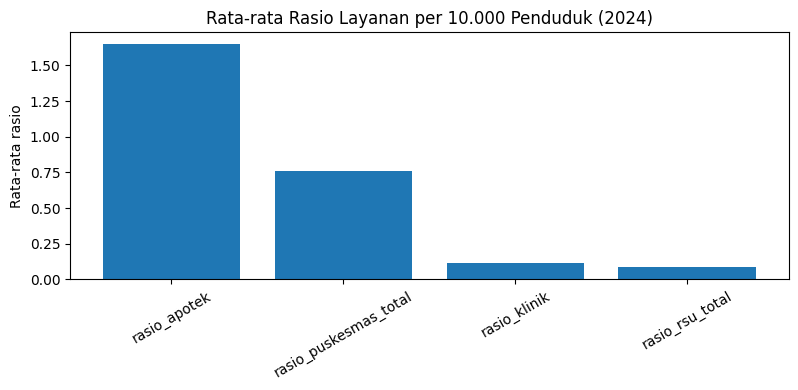

In [3]:
# Bar chart untuk melihat perbandingan rata-rata rasio
means = df[rasio_cols].mean().sort_values(ascending=False)

plt.figure(figsize=(8,4))
plt.bar(means.index, means.values)
plt.xticks(rotation=30)
plt.title("Rata-rata Rasio Layanan per 10.000 Penduduk (2024)")
plt.ylabel("Rata-rata rasio")
plt.tight_layout()
plt.savefig(str(figures_dir / "03_ratarata_rasio_layanan_2024.png"), dpi=200, bbox_inches="tight")
plt.show()


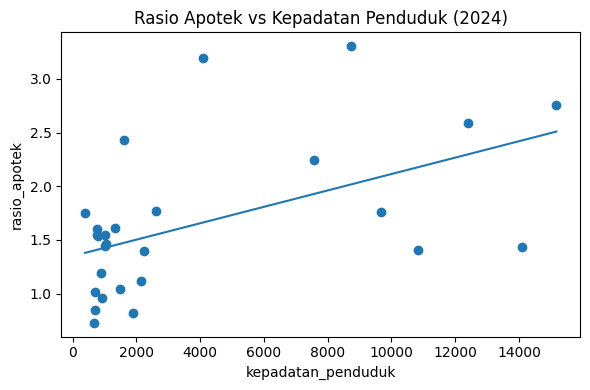

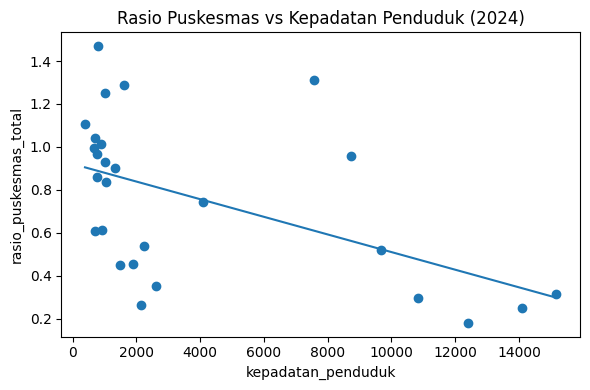

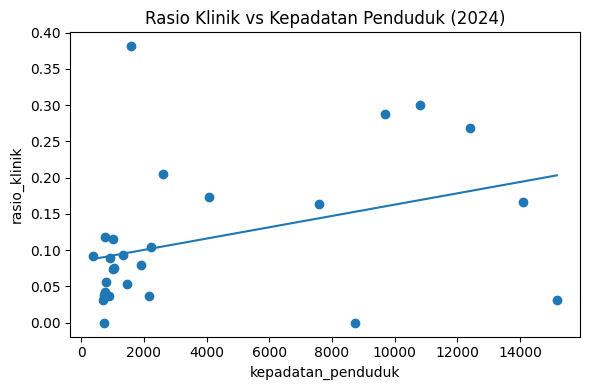

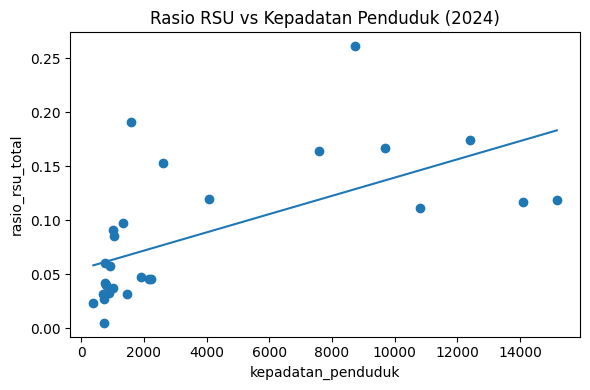

In [4]:
from pathlib import Path

def scatter_with_fit(x_col, y_col, title=None, save_path=None):
    x = df[x_col].values
    y = df[y_col].values

    plt.figure(figsize=(6,4))
    plt.scatter(x, y)

    # line fit sederhana
    m, b = np.polyfit(x, y, 1)
    xs = np.linspace(x.min(), x.max(), 100)
    plt.plot(xs, m*xs + b)
    plt.xlabel(x_col); plt.ylabel(y_col)
    plt.title(title if title else f"{y_col} vs {x_col}")
    plt.tight_layout()
    # simpan gambar (PNG) kalau save_path diisi
    if save_path:
        Path(save_path).parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(str(save_path), dpi=200, bbox_inches='tight')
    plt.show()

# gunakan figures_dir
scatter_with_fit('kepadatan_penduduk', 'rasio_apotek',
                 'Rasio Apotek vs Kepadatan Penduduk (2024)',
                 save_path=figures_dir / '04_scatter_rasio_apotek_vs_kepadatan.png')
scatter_with_fit('kepadatan_penduduk', 'rasio_puskesmas_total',
                 'Rasio Puskesmas vs Kepadatan Penduduk (2024)',
                 save_path=figures_dir / '05_scatter_rasio_puskesmas_vs_kepadatan.png')
scatter_with_fit('kepadatan_penduduk', 'rasio_klinik',
                 'Rasio Klinik vs Kepadatan Penduduk (2024)',
                 save_path=figures_dir / '06_scatter_rasio_klinik_vs_kepadatan.png')
scatter_with_fit('kepadatan_penduduk', 'rasio_rsu_total',
                 'Rasio RSU vs Kepadatan Penduduk (2024)',
                 save_path=figures_dir / '07_scatter_rasio_rsu_total_vs_kepadatan.png')


In [5]:
# Identifikasi kab/kota rasio terendah & tertinggi
def top_bottom(metric, n=5):
    bottom = df.sort_values(metric)[["kab_kota", metric, "kelas_layanan"]].head(n).reset_index(drop=True)
    top = df.sort_values(metric, ascending=False)[["kab_kota", metric, "kelas_layanan"]].head(n).reset_index(drop=True)
    return bottom, top

metrics = ["rasio_apotek", "rasio_puskesmas_total", "rasio_klinik", "rasio_rsu_total", "skor_layanan"]

for m in metrics:
    bottom, top = top_bottom(m, n=5)
    print(f"\n===== {m} | 5 TERENDAH =====")
    display(bottom)
    print(f"===== {m} | 5 TERTINGGI =====")
    display(top)



===== rasio_apotek | 5 TERENDAH =====


,kab_kota,rasio_apotek,kelas_layanan
0,KABUPATEN SUKABUMI,0.728570,Rendah
1,KABUPATEN BOGOR,0.820222,Rendah
2,KABUPATEN CIANJUR,0.846892,Rendah
3,KABUPATEN INDRAMAYU,0.961274,Rendah
4,KABUPATEN TASIKMALAYA,1.015011,Rendah


===== rasio_apotek | 5 TERTINGGI =====


,kab_kota,rasio_apotek,kelas_layanan
0,KOTA CIREBON,3.305657,Tinggi
1,KOTA TASIKMALAYA,3.197190,Tinggi
2,KOTA BANDUNG,2.760890,Sedang
3,KOTA BEKASI,2.586951,Tinggi
4,KOTA BANJAR,2.431501,Tinggi



===== rasio_puskesmas_total | 5 TERENDAH =====


...

,kab_kota,rasio_rsu_total,kelas_layanan
0,KOTA CIREBON,0.260973,Tinggi
1,KOTA BANJAR,0.190706,Tinggi
2,KOTA BEKASI,0.173976,Tinggi
3,KOTA BOGOR,0.166915,Tinggi
4,KOTA SUKABUMI,0.164044,Tinggi



===== skor_layanan | 5 TERENDAH =====


,kab_kota,skor_layanan,kelas_layanan
0,KABUPATEN BANDUNG,-0.910243,Rendah
1,KABUPATEN CIANJUR,-0.843022,Rendah
2,KABUPATEN BANDUNG BARAT,-0.822972,Rendah
3,KABUPATEN BOGOR,-0.771693,Rendah
4,KABUPATEN TASIKMALAYA,-0.669555,Rendah


===== skor_layanan | 5 TERTINGGI =====


,kab_kota,skor_layanan,kelas_layanan
0,KOTA BANJAR,1.749353,Tinggi
1,KOTA CIREBON,1.138263,Tinggi
2,KOTA SUKABUMI,1.028243,Tinggi
3,KOTA TASIKMALAYA,0.836751,Tinggi
4,KOTA BEKASI,0.685918,Tinggi


In [6]:
# Simpan semua grafik & tabel ke folder outputs 
fig_dir = figures_dir
tab_dir = tables_dir

with pd.ExcelWriter(str(tab_dir / 'ranking_top_bottom_2024.xlsx')) as w:
    for m in metrics:
        bottom, top = top_bottom(m, n=5)
        bottom.to_excel(w, sheet_name=f'{m}_bottom', index=False)
        top.to_excel(w, sheet_name=f'{m}_top', index=False)

print('Saved ranking tables to:', (tab_dir / 'ranking_top_bottom_2024.xlsx').resolve())

Saved ranking tables to: C:\Users\femmy\OneDrive\Documents\6. Semester 6\tugas_akhir_machine_learning-main\outputs\tables\ranking_top_bottom_2024.xlsx


In [7]:
import re
import geopandas as gpd

# gunakan path relatif untuk excel & geojson
xlsx_candidates = [
    Path('data') / 'master' / 'Master Data - fitur & label.xlsx',
    Path('..') / 'data' / 'master' / 'Master Data - fitur & label.xlsx',
    Path.cwd().parent / 'data' / 'master' / 'Master Data - fitur & label.xlsx',
]
geo_candidates = [
    Path('data') / 'geo' / 'Jabar_By_Kab.geojson',
    Path('..') / 'data' / 'geo' / 'Jabar_By_Kab.geojson',
    Path.cwd().parent / 'data' / 'geo' / 'Jabar_By_Kab.geojson',
]
xlsx_path = next((p for p in xlsx_candidates if p.exists()), xlsx_candidates[0])
geo_path = next((p for p in geo_candidates if p.exists()), geo_candidates[0])

out_dir = figures_dir
out_dir.mkdir(parents=True, exist_ok=True)

df = pd.read_excel(xlsx_path)
gdf = gpd.read_file(geo_path)

print('df:', df.shape)
print('gdf:', gdf.shape)
print('Kolom geojson:', gdf.columns.tolist())
gdf.head()

df: (27, 19)
gdf: (27, 7)
Kolom geojson: ['code', 'name', 'level', 'latitude', 'longitude', 'parent_code', 'geometry']


,code,name,level,latitude,longitude,parent_code,geometry
0,32.04,Kabupaten Bandung,regency,-7.097588,107.608727,32,"POLYGON ((107.75 -6.81285, 107.74099 -6.85487,..."
1,32.16,Kabupaten Bekasi,regency,-6.219747,107.121712,32,"POLYGON ((107.0159 -5.92681, 107.03603 -5.9364..."
2,32.17,Kabupaten Bandung Barat,regency,-6.890438,107.414982,32,"POLYGON ((107.41211 -6.68997, 107.42514 -6.700..."
3,32.01,Kabupaten Bogor,regency,-6.559797,106.767047,32,"POLYGON ((106.97087 -6.30288, 106.98095 -6.315..."
4,32.03,Kabupaten Cianjur,regency,-7.130889,107.159202,32,"POLYGON ((107.23023 -6.60494, 107.26839 -6.644..."


In [8]:
import re

def norm_name(s: str) -> str:
    s = str(s).upper().strip()
    s = re.sub(r"\s+", " ", s)
    s = re.sub(r"\bKABUPATEN\b|\bKAB\.?\b|\bKOTA\b", "", s)
    s = re.sub(r"[^A-Z0-9\s]", " ", s)
    return " ".join(s.split())


# ======================
# 1. NORMALISASI DATA EXCEL
# ======================
if "kab_kota" in df.columns:
    df["nama_norm"] = df["kab_kota"].apply(norm_name)
else:
    df["nama_norm"] = df.iloc[:, 0].apply(norm_name)


# ======================
# 2. DETEKSI KOLOM NAMA DI GEOJSON
# ======================
candidates = [
    c for c in gdf.columns
    if any(k in c.lower() for k in ("nama", "name", "kab", "kota"))
]

name_col = None
for c in candidates:
    sample = gdf[c].astype(str).head(10)
    if sample.str.contains(r"[A-Za-z]").any():
        name_col = c
        break

if name_col is None:
    raise ValueError("Kolom nama wilayah tidak ditemukan di GeoJSON")

print("Using geo name column:", name_col)


# ======================
# 3. NORMALISASI GEOJSON
# ======================
gdf["nama_norm"] = gdf[name_col].apply(norm_name)

# LABEL PETA SELALU DARI GEOJSON
gdf["label_peta"] = gdf[name_col]


# ======================
# 4. MERGE
# ======================
merged = gdf.merge(
    df,
    on="nama_norm",
    how="left"
)


# ======================
# 5. CEK YANG GAGAL MATCH
# ======================
missing = merged[merged[df.columns.difference(["nama_norm"])].isna().all(axis=1)]
print("Yang belum match:", missing.shape[0])
display(missing[[name_col, "nama_norm"]].head(30))


Using geo name column: name
Yang belum match: 0


,name,nama_norm


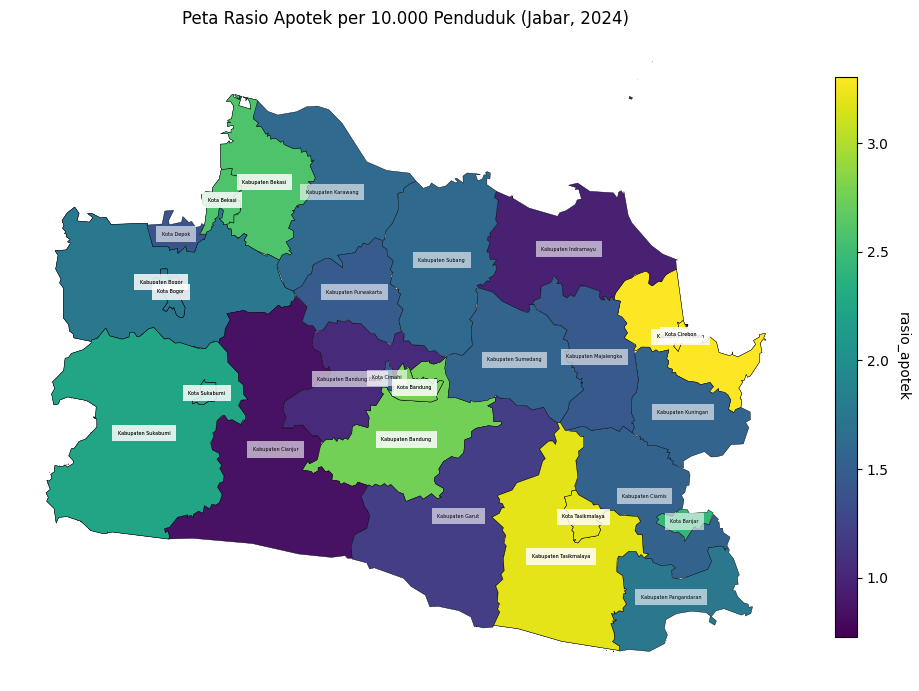

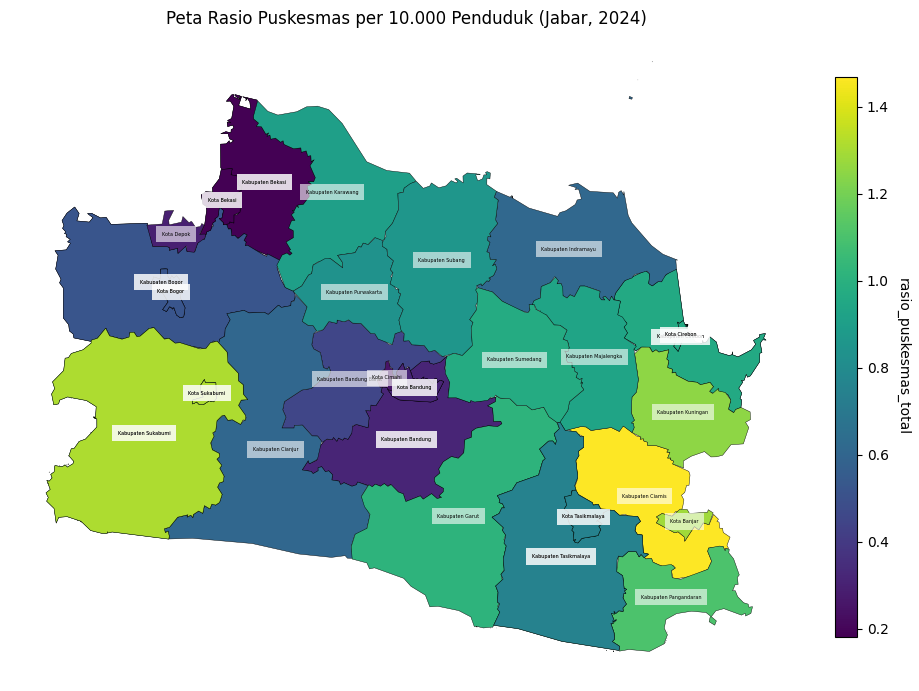

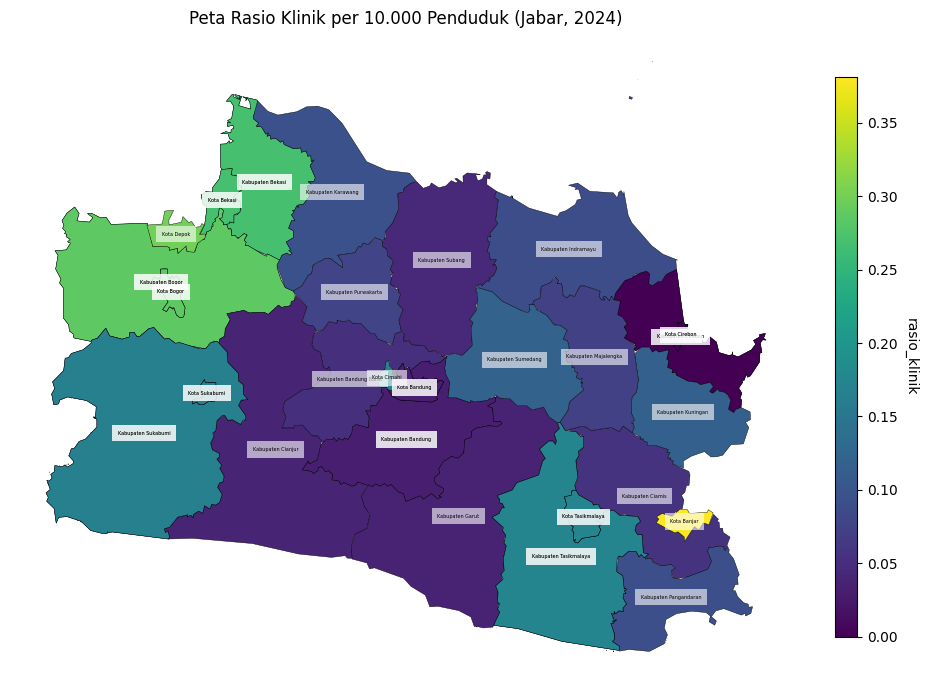

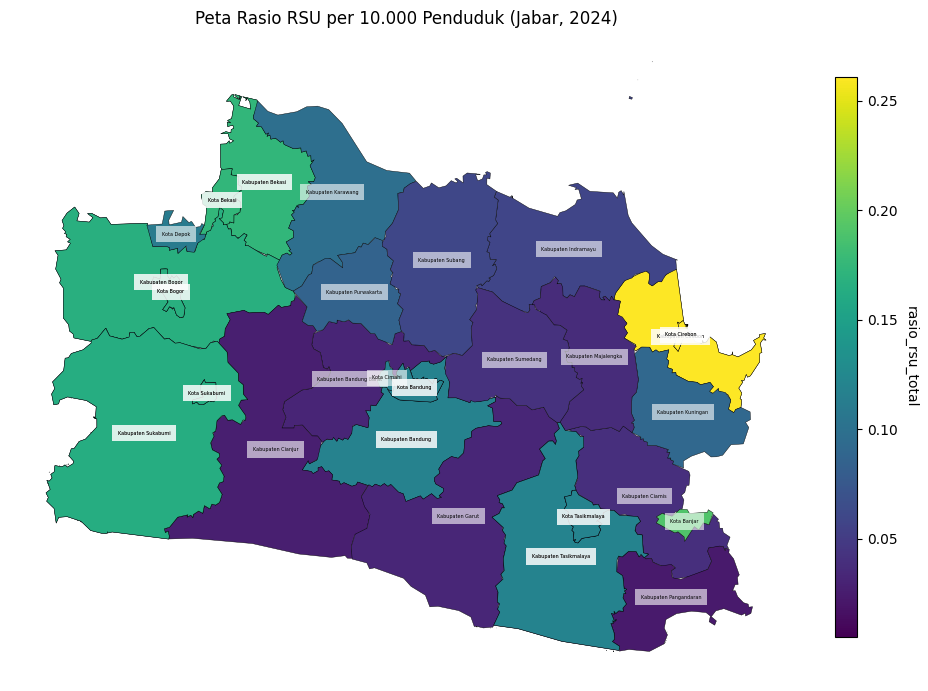

In [9]:
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from matplotlib.patches import Patch
from pathlib import Path
import pandas as pd
import numpy as np
import math

# Define figures_dir
figures_dir = Path('../outputs/figures')

# gunakan figures_dir relatif sebagai output
out_dir = figures_dir
out_dir.mkdir(parents=True, exist_ok=True)


def plot_choropleth(gdfm, col, title, filename, label_col='display_name', cmap='viridis', annotate=True, annotate_fontsize=3):
    """Plot choropleth dengan colorbar vertikal.
    Re-project ke CRS terproyeksi untuk perhitungan centroid yang aman.
    Hindari tight_layout() pada figure dengan axes yang diposisikan manual.
    """
    # STEP 1: Persiapkan GeoDataFrame untuk plotting (reproject ke EPSG:3857 jika CRS geografis)
    try:
        if getattr(gdfm, 'crs', None) is not None and not gdfm.crs.is_projected:
            gdfm_plot = gdfm.to_crs(epsg=3857)
        else:
            gdfm_plot = gdfm.copy()
    except Exception:
        gdfm_plot = gdfm.copy()

    # STEP 2: Pastikan kolom label tersedia; gunakan fallback jika perlu
    if label_col not in gdfm_plot.columns:
        for cand in ('display_name', 'kab_kota', 'kab_kota_df', 'kab_kota_geo', 'nama_norm', 'name', 'NAME', 'label_peta'):
            if cand in gdfm_plot.columns:
                gdfm_plot[label_col] = gdfm_plot[cand].astype(str)
                break
        else:
            if 'nama_norm' in gdfm_plot.columns:
                if 'area_type' in gdfm_plot.columns:
                    repl = gdfm_plot['area_type'].map({'KAB': ' (KAB)', 'KOTA': ' (KOTA)'}).fillna('')
                    gdfm_plot[label_col] = gdfm_plot['nama_norm'].astype(str) + repl
                else:
                    gdfm_plot[label_col] = gdfm_plot['nama_norm'].astype(str)
            else:
                gdfm_plot[label_col] = gdfm_plot.index.astype(str)

    # STEP 3: Buat figure dengan axes terpisah untuk map, colorbar
    fig = plt.figure(figsize=(11,8))
    ax_map = fig.add_axes([0.03, 0.06, 0.72, 0.88])   # main map
    ax_cbar = fig.add_axes([0.78, 0.15, 0.02, 0.7])   # colorbar

    # STEP 4: Plot choropleth (peta berwarna berdasarkan nilai kolom yang dipilih)
    vals = gdfm_plot[col] if col in gdfm_plot.columns else pd.Series(dtype=float)
    if vals.dropna().empty:
        gdfm_plot.plot(color='lightgrey', ax=ax_map, edgecolor='black')
    else:
        vmin = float(vals.min()); vmax = float(vals.max())
        gdfm_plot.plot(column=col, ax=ax_map, cmap=cmap, linewidth=0.3, edgecolor='black',
                  missing_kwds={'color':'lightgrey', 'label':'Tidak ada data'}, legend=False)

        # STEP 5: Tambahkan colorbar (skala warna numerik)
        sm = ScalarMappable(norm=Normalize(vmin=vmin, vmax=vmax), cmap=cmap)
        sm._A = []
        cbar = fig.colorbar(sm, cax=ax_cbar)
        cbar.set_label(col, rotation=270, labelpad=15)

        # Add text labels 'Tinggi' and 'Rendah' to the colorbar
        cbar.ax.text(0.5, 1.02, 'Tinggi', transform=cbar.ax.transAxes, ha='center', va='bottom', fontsize=8)
        cbar.ax.text(0.5, -0.02, 'Rendah', transform=cbar.ax.transAxes, ha='center', va='top', fontsize=8)

    ax_map.set_title(title)
    ax_map.set_axis_off()

    # STEP 6: Anotasi label wilayah di atas centroid (jika annotate=True)
    if annotate and label_col in gdfm_plot.columns:
        # Hitung centroid dalam CRS terproyeksi untuk posisi yang akurat
        try:
            if getattr(gdfm_plot, 'crs', None) is not None and not gdfm_plot.crs.is_projected:
                cents = gdfm_plot.to_crs(epsg=3857).geometry.centroid
            else:
                cents = gdfm_plot.geometry.centroid
        except Exception:
            cents = gdfm_plot.geometry.centroid

        # Hitung jumlah kemunculan setiap label (untuk deteksi duplikat)
        names = gdfm_plot[label_col].fillna('').astype(str)
        counts = names.value_counts()

        # Iterasi setiap wilayah dan tambahkan label teks di pusatnya
        for idx, row in gdfm_plot.iterrows():
            try:
                raw_lbl = row.get(label_col, '')
                if not pd.notna(raw_lbl) or str(raw_lbl).strip() == '':
                    continue
                lbl = str(raw_lbl)
                # Hapus semua angka dari label (hanya tampilkan nama daerah)
                lbl = re.sub(r'\d+', '', lbl)
                lbl = ' '.join(lbl.split()).strip().upper()
                if not lbl or lbl.strip() == '':
                    continue
                # Jika ada label duplikat, tambahkan suffix (Kab) / (Kota) untuk membedakan
                if counts.get(lbl, 0) > 1:
                    if 'area_type' in gdfm_plot.columns:
                        at = row.get('area_type', '')
                        if str(at).upper().startswith('KAB'):
                            lbl = f"{lbl} (KAB)"
                        elif str(at).upper().startswith('KOT'):
                            lbl = f"{lbl} (KOTA)"

                x = cents.loc[idx].x
                y = cents.loc[idx].y
                ax_map.text(x, y, lbl, fontsize=annotate_fontsize, ha='center', va='center',
                            color='black', weight='bold', bbox=dict(facecolor='white', alpha=0.6, linewidth=0), zorder=10, clip_on=True)
            except Exception:
                continue

    # STEP 7: Atur layout dan simpan gambar
    fig.subplots_adjust(left=0.03, right=0.9, top=0.96, bottom=0.04)
    fig.savefig(str(out_dir / filename), dpi=220, bbox_inches='tight')
    plt.show()

# pemanggilan (gunakan relative figures_dir)
plot_choropleth(merged, 'rasio_apotek', 'Peta Rasio Apotek per 10.000 Penduduk (Jabar, 2024)', '08_map_rasio_apotek_2024.png', label_col='label_peta')
plot_choropleth(merged, 'rasio_puskesmas_total', 'Peta Rasio Puskesmas per 10.000 Penduduk (Jabar, 2024)', '09_map_rasio_puskesmas_2024.png', label_col='label_peta')
plot_choropleth(merged, 'rasio_klinik', 'Peta Rasio Klinik per 10.000 Penduduk (Jabar, 2024)', '10_map_rasio_klinik_2024.png', label_col='label_peta')
plot_choropleth(merged, 'rasio_rsu_total', 'Peta Rasio RSU per 10.000 Penduduk (Jabar, 2024)', '11_map_rasio_rsu_2024.png', label_col='label_peta')

In [ ]:
# ==========================================
# VISUALISASI FEATURE IMPORTANCE
# ==========================================
# Load data feature importance (gunakan path relatif)
fi_path = Path('../outputs/feature_importance.csv')

if fi_path.exists():
    # Baca csv, kolom pertama sebagai index
    df_fi = pd.read_csv(fi_path, index_col=0)
    
    # Rename kolom skor (biasanya bernama '0' atau 'importance')
    if not df_fi.empty:
        df_fi.columns = ['Importance']
        # Urutkan dari kecil ke besar untuk barh chart
        df_fi = df_fi.sort_values('Importance', ascending=True)
        
        plt.figure(figsize=(10, 6))
        plt.barh(df_fi.index, df_fi['Importance'], color='teal')
        plt.title('Tingkat Kepentingan Fitur (Feature Importance)')
        plt.xlabel('Importance Score')
        plt.grid(axis='x', linestyle='--', alpha=0.6)
        plt.tight_layout()
        
        # Simpan output ke figures_dir (yang sudah didefinisikan sebelumnya)
        save_path = figures_dir / 'tingkat kepentingan fitur important.png'
        plt.savefig(str(save_path), dpi=200, bbox_inches='tight')
        plt.show()
        print(f'Grafik tersimpan di: {save_path.resolve()}')
    else:
        print('Data feature importance kosong.')
else:
    print(f'File tidak ditemukan: {fi_path.resolve()}')